In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv("data\loan.csv")

In [6]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
df.drop(columns=["loan_id"], inplace=True)

In [8]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [10]:
X = df.iloc[:, :-1]

In [11]:
y = df.iloc[:, -1]

In [12]:
y

0        Approved
1        Rejected
2        Rejected
3        Rejected
4        Rejected
          ...    
4264     Rejected
4265     Approved
4266     Rejected
4267     Approved
4268     Approved
Name:  loan_status, Length: 4269, dtype: object

#### Create pipeline


In [ ]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

In [14]:
num_features

Index([' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term',
       ' cibil_score', ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value'],
      dtype='object')

In [15]:
cat_features

Index([' education', ' self_employed'], dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [ ]:
X = preprocessor.fit_transform(X)

In [18]:
X

array([[ 1.        ,  0.        ,  1.        , ...,  2.877289  ,
         0.83202837,  0.93030441],
       [ 0.        ,  1.        ,  0.        , ..., -0.63192107,
        -0.69499321, -0.51593638],
       [ 1.        ,  0.        ,  1.        , ..., -0.10781827,
         1.99651964,  2.40731629],
       ...,
       [ 0.        ,  1.        ,  1.        , ...,  1.69236092,
         0.3266831 ,  0.71490685],
       [ 0.        ,  1.        ,  1.        , ..., -0.97372725,
        -0.11274758,  0.25334064],
       [ 1.        ,  0.        ,  1.        , ...,  1.55563845,
         2.26017804,  2.16114764]])

In [ ]:
from sklearn.model_selection import train_test_split

# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((3415, 13), (854, 13))

#### Create an Evaluate Function to give all metrics after model Training


In [28]:
def evaluate_model(true, predicted):
    accuracy = accuracy_score(true, predicted)
    recall = recall_score(true, predicted, average='weighted')
    precision = precision_score(true, predicted, average='weighted')
    cm = confusion_matrix(true, predicted)

    return accuracy, recall, precision, cm

In [36]:
models = {
  "Logistic Regression" :  LogisticRegression(),
  "KNN-Classifier": KNeighborsClassifier(),
  "Decision Tree": DecisionTreeClassifier(),
  "GradientBoostClassifier": GradientBoostingClassifier(),
  "RandomForestClassifier": RandomForestClassifier(),
}

model_list = []
acc_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    # make prediction 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_accuracy, model_train_recall, model_train_precision, model_train_cm = evaluate_model(y_train, y_train_pred)

    model_test_accuracy, model_test_recall, model_test_precision, model_test_cm = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print(f"- Accuracy: {model_train_accuracy}")
    print(f"- Recall: {model_train_recall}")
    print(f"- Precision: {model_train_precision}")
    print(f"- Confusion Matrix: {model_train_cm}")

    print('------------------------------------------')
    
    print('Model performance for Test set')
    print(f"- Accuracy: {model_test_accuracy}")
    print(f"- Recall: {model_test_recall}")
    print(f"- Precision: {model_test_precision}")
    print(f"- Confusion Matrix: {model_test_cm}")
    acc_list.append(model_test_accuracy)

    print('='*35)
    print("\n")


Logistic Regression
Model performance for Training set
- Accuracy: 0.9200585651537335
- Recall: 0.9200585651537335
- Precision: 0.9200707258152233
- Confusion Matrix: [[1983  137]
 [ 136 1159]]
------------------------------------------
Model performance for Test set
- Accuracy: 0.9039812646370023
- Recall: 0.9039812646370023
- Precision: 0.9036959199532547
- Confusion Matrix: [[498  38]
 [ 44 274]]


KNN-Classifier
Model performance for Training set
- Accuracy: 0.9431918008784773
- Recall: 0.9431918008784773
- Precision: 0.9431753656847415
- Confusion Matrix: [[2024   96]
 [  98 1197]]
------------------------------------------
Model performance for Test set
- Accuracy: 0.8957845433255269
- Recall: 0.8957845433255269
- Precision: 0.8972799569382433
- Confusion Matrix: [[484  52]
 [ 37 281]]


Decision Tree
Model performance for Training set
- Accuracy: 1.0
- Recall: 1.0
- Precision: 1.0
- Confusion Matrix: [[2120    0]
 [   0 1295]]
------------------------------------------
Model per

In [37]:
acc_list

[0.9039812646370023,
 0.8957845433255269,
 0.9742388758782201,
 0.977751756440281,
 0.9800936768149883]

In [39]:
pd.DataFrame(list(zip(model_list, acc_list)), columns=['Model Name', 'Accuracy Score']).sort_values(by=['Accuracy Score'], ascending=False)

,Model Name,Accuracy Score
4,RandomForestClassifier,0.980094
3,GradientBoostClassifier,0.977752
2,Decision Tree,0.974239
0,Logistic Regression,0.903981
1,KNN-Classifier,0.895785


#### RandomForestClassifier

In [42]:
rf = RandomForestClassifier()
rf = rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f"%accuracy)

 Accuracy of the model is 97.66


Text(0, 0.5, 'Predicted')

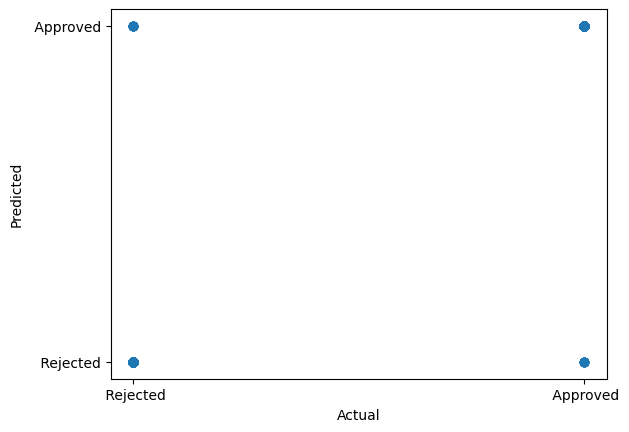

In [43]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")